In [ ]:
import zipfile
import os

zip_path = "/content/LesionDetection_3.v38-yolov8dinamikcrop.coco-segmentation.zip"
extract_path = "oral_cancer_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")


Dataset extracted


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    print("Number of images:", len(files))
    break

Folder: oral_cancer_dataset
Number of images: 2


In [ ]:
import os
import shutil

base_path = "oral_cancer_dataset"

splits = ["train", "valid", "test"]

for split in splits:

    split_path = os.path.join(base_path, split)

    images_folder = os.path.join(split_path, "images")
    masks_old_folder = os.path.join(split_path, "mask")
    masks_new_folder = os.path.join(split_path, "masks")

    # Create new folders
    os.makedirs(images_folder, exist_ok=True)
    os.makedirs(masks_new_folder, exist_ok=True)

    # Move images to images/
    for file in os.listdir(split_path):
        if file.endswith((".jpg", ".png", ".jpeg")):
            src = os.path.join(split_path, file)
            dst = os.path.join(images_folder, file)
            shutil.move(src, dst)

    # Move masks to masks/
    if os.path.exists(masks_old_folder):
        for file in os.listdir(masks_old_folder):
            src = os.path.join(masks_old_folder, file)
            dst = os.path.join(masks_new_folder, file)
            shutil.move(src, dst)

        # remove old mask folder
        os.rmdir(masks_old_folder)

print("✅ Folder structure fixed successfully!")

✅ Folder structure fixed successfully!


In [ ]:
import os

train_images = os.path.join("/content/oral_cancer_dataset", "train", "images")
valid_images = os.path.join("/content/oral_cancer_dataset", "valid", "images")
test_images  = os.path.join("/content/oral_cancer_dataset", "test", "images")

SAM

In [ ]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python matplotlib pycocotools
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import cv2
import numpy as np
import os
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device)

mask_generator = SamAutomaticMaskGenerator(sam)

print("SAM ready on", device)

SAM ready on cuda


In [ ]:
sam_output = "/content/oral_cancer_dataset" + "/sam_masks"

os.makedirs(sam_output + "/train", exist_ok=True)
os.makedirs(sam_output + "/valid", exist_ok=True)
os.makedirs(sam_output + "/test", exist_ok=True)

In [ ]:
def generate_sam_masks(input_folder, output_folder):

    image_files = os.listdir(input_folder)

    for img_name in image_files:

        if img_name.endswith(('.png','.jpg','.jpeg')):

            img_path = os.path.join(input_folder, img_name)

            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            masks = mask_generator.generate(image)

            if len(masks) == 0:
                continue

            largest_mask = max(masks, key=lambda x: x['area'])

            lesion_mask = largest_mask['segmentation']

            mask_save = (lesion_mask * 255).astype(np.uint8)

            save_name = img_name.split('.')[0] + "_sam_mask.png"

            cv2.imwrite(os.path.join(output_folder, save_name), mask_save)

    print("Done:", output_folder)

In [ ]:
generate_sam_masks("/content/oral_cancer_dataset/train/images", sam_output + "/train")
generate_sam_masks("/content/oral_cancer_dataset/valid/images", sam_output + "/valid")
generate_sam_masks("/content/oral_cancer_dataset/test/images", sam_output + "/test")

Done: /content/oral_cancer_dataset/sam_masks/train
Done: /content/oral_cancer_dataset/sam_masks/valid
Done: /content/oral_cancer_dataset/sam_masks/test


Image path: /content/oral_cancer_dataset/train/images/P167_jpg.rf.753de94711676e7bbe780c205fac29ca.jpg
Mask path: /content/oral_cancer_dataset/sam_masks/train/P167_jpg_sam_mask.png


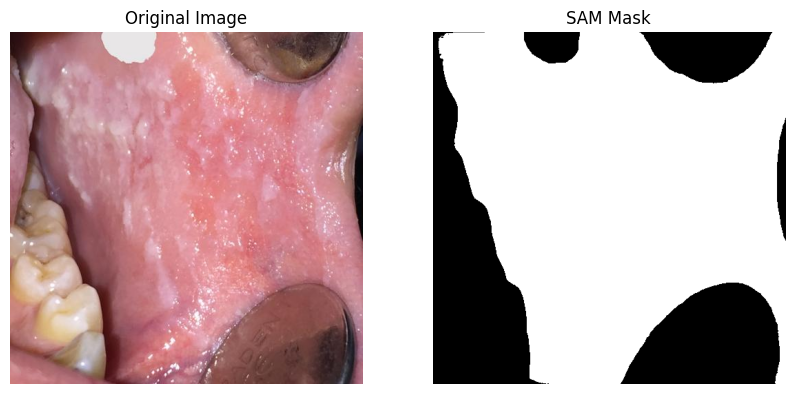

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

dataset_path = "/content/oral_cancer_dataset"

train_images = dataset_path + "/train/images"
sam_masks    = dataset_path + "/sam_masks/train"

# select random image
img_name = random.choice(os.listdir(train_images))

img_path  = os.path.join(train_images, img_name)
mask_path = os.path.join(sam_masks, img_name.split('.')[0] + "_sam_mask.png")

print("Image path:", img_path)
print("Mask path:", mask_path)

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("SAM Mask")
plt.axis("off")

plt.show()

In [ ]:
dataset_path = "/content/oral_cancer_dataset"

train_images = dataset_path + "/train/images"
train_masks  = dataset_path + "/train/masks"

sam_masks    = dataset_path + "/sam_masks/train"

valid_images = dataset_path + "/valid/images"
valid_masks  = dataset_path + "/valid/masks"

In [ ]:
!pip install segmentation-models-pytorch
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp

In [ ]:
refined_mask_path = dataset_path + "/refined_masks/train"
os.makedirs(refined_mask_path, exist_ok=True)

image_list = os.listdir(train_masks)

for mask_name in image_list:

    gt_path = os.path.join(train_masks, mask_name)

    sam_name = mask_name.split('.')[0] + "_sam_mask.png"
    sam_path = os.path.join(sam_masks, sam_name)

    if not os.path.exists(sam_path):
        continue

    gt_mask  = cv2.imread(gt_path, 0)
    sam_mask = cv2.imread(sam_path, 0)

    gt_mask  = gt_mask / 255
    sam_mask = sam_mask / 255

    # Combine masks using OR operation
    refined_mask = np.logical_or(gt_mask, sam_mask).astype(np.uint8) * 255

    cv2.imwrite(os.path.join(refined_mask_path, mask_name), refined_mask)

print("Refined masks created")

Refined masks created


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset

def get_sam_mask(image_name, sam_dir):

    base = image_name.split(".rf")[0]

    sam_name = base + "_sam_mask.png"

    sam_path = os.path.join(sam_dir, sam_name)

    if os.path.exists(sam_path):
        return sam_path
    else:
        return None


class OralCancerDataset(Dataset):

    def __init__(self, image_dir, original_mask_dir, sam_mask_dir, size=256):

        self.image_dir = image_dir
        self.original_mask_dir = original_mask_dir
        self.sam_mask_dir = sam_mask_dir
        self.size = size

        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)

        original_mask_path = os.path.join(self.original_mask_dir, img_name)

        sam_mask_path = get_sam_mask(img_name, self.sam_mask_dir)

        # Load image
        image = cv2.imread(img_path)
        image = cv2.resize(image, (self.size, self.size))
        image = image / 255.0

        # Load SAM mask if exists
        if sam_mask_path is not None:

            mask = cv2.imread(sam_mask_path, 0)

        else:

            mask = cv2.imread(original_mask_path, 0)

        mask = cv2.resize(mask, (self.size, self.size))
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
train_dataset = OralCancerDataset(

    image_dir="/content/oral_cancer_dataset/train/images",

    original_mask_dir="/content/oral_cancer_dataset/train/masks",

    sam_mask_dir="/content/oral_cancer_dataset/sam_masks/train"
)

valid_dataset = OralCancerDataset(

    image_dir="/content/oral_cancer_dataset/valid/images",

    original_mask_dir="/content/oral_cancer_dataset/valid/masks",

    sam_mask_dir="/content/oral_cancer_dataset/sam_masks/valid"
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)

SWIN Transformer

In [ ]:
!pip install segmentation-models-pytorch timm

Swin transfer u net model

In [ ]:
import segmentation_models_pytorch as smp
import torch
import torch.optim as optim

model = smp.Unet(
    encoder_name="mit_b0",  # Changed from "timm-swin-tiny-patch4-window7-224" to a supported Mix Transformer encoder
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    decoder_attention_type="scse"
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

LOSS

In [ ]:
loss_fn = smp.losses.DiceLoss(mode="binary")

Optimizer

In [ ]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

Learning Rate Scheduler

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

Training Loop

In [ ]:
EPOCHS = 100

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print("Epoch:", epoch+1, "Train Loss:", train_loss/len(train_loader))

Epoch: 1 Train Loss: 0.26612735495847817
Epoch: 2 Train Loss: 0.22224509365418377
Epoch: 3 Train Loss: 0.19379091262817383
Epoch: 4 Train Loss: 0.1724829253028421
Epoch: 5 Train Loss: 0.1533121957498438
Epoch: 6 Train Loss: 0.14051854961058674
Epoch: 7 Train Loss: 0.13028037197449627
Epoch: 8 Train Loss: 0.11454999096253339
Epoch: 9 Train Loss: 0.11175086918999166
Epoch: 10 Train Loss: 0.10429463316412534
Epoch: 11 Train Loss: 0.09921836151796229
Epoch: 12 Train Loss: 0.08622167040320004
Epoch: 13 Train Loss: 0.07831766675500308
Epoch: 14 Train Loss: 0.07916042383979349
Epoch: 15 Train Loss: 0.08018351653042961
Epoch: 16 Train Loss: 0.06833657797645121
Epoch: 17 Train Loss: 0.060112003017874324
Epoch: 18 Train Loss: 0.057007505613214826
Epoch: 19 Train Loss: 0.05152301227345186
Epoch: 20 Train Loss: 0.05699083033730002
Epoch: 21 Train Loss: 0.04866753255619722
Epoch: 22 Train Loss: 0.050180512316086716
Epoch: 23 Train Loss: 0.05263719488592709
Epoch: 24 Train Loss: 0.04733119291417739


Validation loop

In [ ]:
import torch.nn.functional as F

def dice_score(preds, masks):
    smooth = 1e-6
    intersection = (preds * masks).sum()
    union = preds.sum() + masks.sum()
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def iou_score(preds, masks):
    smooth = 1e-6
    intersection = (preds * masks).sum()
    union = preds.sum() + masks.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

def precision_score(preds, masks):
    smooth = 1e-6
    true_positives = (preds * masks).sum()
    predicted_positives = preds.sum()
    precision = (true_positives + smooth) / (predicted_positives + smooth)
    return precision

def recall_score(preds, masks):
    smooth = 1e-6
    true_positives = (preds * masks).sum()
    actual_positives = masks.sum()
    recall = (true_positives + smooth) / (actual_positives + smooth)
    return recall


model.eval()

valid_loss = 0
dice_total = 0
iou_total = 0
precision_total = 0
recall_total = 0

with torch.no_grad():

    for images, masks in valid_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = loss_fn(preds, masks)

        valid_loss += loss.item()

        preds = torch.sigmoid(preds)

        dice_total += dice_score(preds, masks)
        iou_total += iou_score(preds, masks)
        precision_total += precision_score(preds, masks)
        recall_total += recall_score(preds, masks)

n = len(valid_loader)

print("Validation Loss:", valid_loss/n)
print("Dice Score:", dice_total/n)
print("IoU:", iou_total/n)
print("Precision:", precision_total/n)
print("Recall:", recall_total/n)

Validation Loss: 0.06867828965187073
Dice Score: tensor(0.9310, device='cuda:0')
IoU: tensor(0.8730, device='cuda:0')
Precision: tensor(0.9524, device='cuda:0')
Recall: tensor(0.9151, device='cuda:0')


Visualization

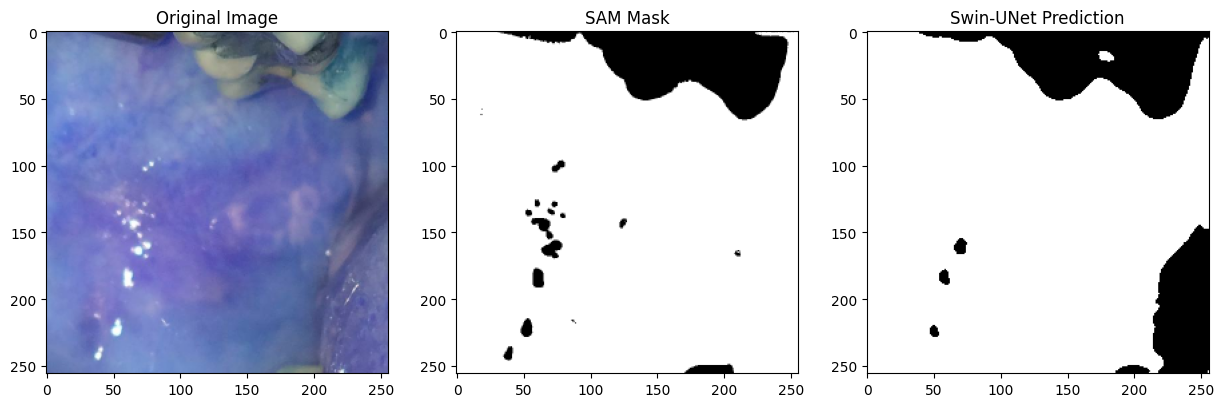

In [ ]:
model.eval()

images, masks = next(iter(valid_loader))

images = images.to(device)

with torch.no_grad():
    preds = model(images)

preds = torch.sigmoid(preds)

idx = 5

image = images[idx].cpu().permute(1,2,0).numpy()
true_mask = masks[idx].cpu().squeeze().numpy()
pred_mask = preds[idx].cpu().squeeze().numpy()

pred_mask = (pred_mask > 0.5).astype(np.uint8)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap="gray")
plt.title("SAM Mask")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Swin-UNet Prediction")

plt.show()

overlay

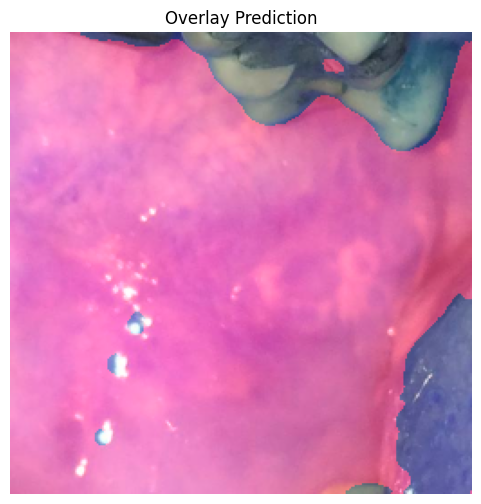

In [ ]:
overlay = image.copy()

overlay[:,:,0] = overlay[:,:,0] + pred_mask * 0.5

plt.figure(figsize=(6,6))

plt.imshow(overlay)

plt.title("Overlay Prediction")

plt.axis("off")

plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

model.eval()

dice_total = 0
iou_total = 0
precision_total = 0
recall_total = 0

count = 0

all_probs = []
all_labels = []

with torch.no_grad():

    for images, masks in valid_loader:

        images = images.cuda()
        masks = masks.cuda()

        preds = model(images)
        preds = torch.sigmoid(preds)

        for i in range(len(preds)):

            # Threshold for metric calculation
            pred_bin = (preds[i] > 0.5).float()

            # Convert tensors to CPU numpy arrays for sklearn metrics
            # Explicitly cast to int to ensure binary classification is recognized
            # pred_bin_np = pred_bin.cpu().numpy().astype(int)
            # masks_i_np = masks[i].cpu().numpy().astype(int)

            # The custom dice_score and iou_score functions (from KS6LuaMlzutr) work with torch tensors
            dice_total += dice_score(pred_bin, masks[i])
            iou_total += iou_score(pred_bin, masks[i])

            # Use custom precision_score and recall_score functions with torch tensors
            precision_total += precision_score(pred_bin, masks[i])
            recall_total += recall_score(pred_bin, masks[i])

            count += 1

            # Store probabilities and labels for curves
            all_probs.extend(preds[i].cpu().numpy().flatten())
            all_labels.extend(masks[i].cpu().numpy().flatten().astype(int)) # Cast to int here


print("Dice Score:", dice_total/count)
print("IoU Score:", iou_total/count)
print("Precision:", precision_total/count)
print("Recall:", recall_total/count)


Dice Score: tensor(0.9005, device='cuda:0')
IoU Score: tensor(0.8639, device='cuda:0')
Precision: tensor(0.9306, device='cuda:0')
Recall: tensor(0.9038, device='cuda:0')


precision- recall curve

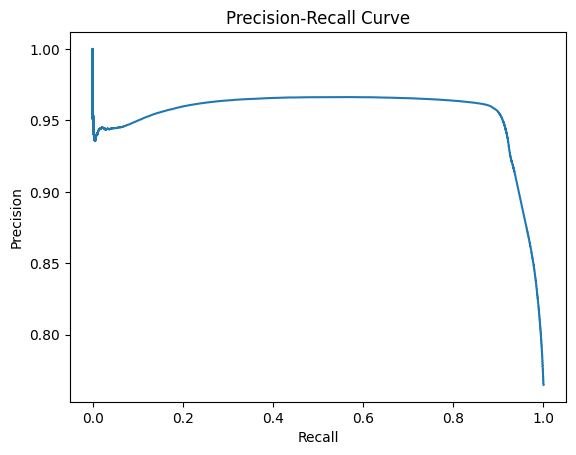

In [ ]:
precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

roc curve

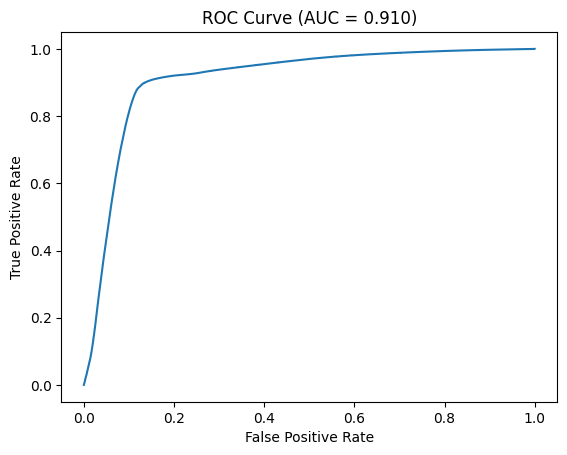

AUC Score: 0.9099545984942848


In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = {:.3f})".format(roc_auc))
plt.show()

print("AUC Score:", roc_auc)

Load sam model

In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"

sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
sam.to("cuda")

predictor = SamPredictor(sam)

Metrics function

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

def dice_score(pred, target):

    intersection = np.sum(pred * target)

    return (2 * intersection) / (np.sum(pred) + np.sum(target) + 1e-6)


def iou_score(pred, target):

    intersection = np.sum(pred * target)

    union = np.sum(pred) + np.sum(target) - intersection

    return intersection / (union + 1e-6)

Generate Prompts from Swin-UNet Mask

In [ ]:
def generate_prompts_from_mask(pred_mask):

    ys, xs = np.where(pred_mask > 0.5)

    if len(xs) == 0:
        return None, None

    cx = int(xs.mean())
    cy = int(ys.mean())

    point = np.array([[cx, cy]])
    label = np.array([1])

    x1 = xs.min()
    x2 = xs.max()
    y1 = ys.min()
    y2 = ys.max()

    box = np.array([x1, y1, x2, y2])

    return (point, label), box

Run SAM with Prompts

In [ ]:
import cv2

def run_sam_prompt(image, prompt_type, pred_mask):

    predictor.set_image(image)

    point_prompt, box_prompt = generate_prompts_from_mask(pred_mask)

    if point_prompt is None:
        return np.zeros_like(pred_mask)

    if prompt_type == "point":

        points, labels = point_prompt

        masks, _, _ = predictor.predict(
            point_coords=points,
            point_labels=labels,
            multimask_output=False
        )

        return masks[0]

    elif prompt_type == "box":

        masks, _, _ = predictor.predict(
            box=box_prompt,
            multimask_output=False
        )

        return masks[0]

    elif prompt_type == "mask":

        mask_resized = cv2.resize(
            pred_mask.astype(np.float32),
            (256,256)
        )

        mask_resized = mask_resized[None,:,:]

        masks, _, _ = predictor.predict(
            mask_input=mask_resized,
            multimask_output=False
        )

        return masks[0]

Evaluate Swin-UNet + SAM

In [ ]:
def evaluate_prompt(prompt_type, data_loader):

    dice_total = 0
    iou_total = 0
    precision_total = 0
    recall_total = 0

    count = 0

    example_mask = None

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for images, masks in data_loader:

            images = images.cuda()
            masks = masks.cuda()

            preds = torch.sigmoid(model(images))

            for i in range(len(images)):

                image_np = images[i].permute(1,2,0).cpu().numpy()
                image_np = (image_np * 255).astype(np.uint8)

                gt_mask = masks[i].cpu().numpy().squeeze()

                pred_mask = preds[i].cpu().numpy().squeeze()

                sam_mask = run_sam_prompt(
                    image_np,
                    prompt_type,
                    pred_mask
                )

                sam_mask_bin = (sam_mask > 0.5).astype(np.uint8)

                y_true = (gt_mask > 0.5).astype(int).flatten()
                y_pred = sam_mask_bin.flatten()

                dice = dice_score(sam_mask_bin, gt_mask)
                iou = iou_score(sam_mask_bin, gt_mask)

                precision = precision_score(y_true, y_pred, zero_division=0)
                recall = recall_score(y_true, y_pred, zero_division=0)

                dice_total += dice
                iou_total += iou
                precision_total += precision
                recall_total += recall

                count += 1

                if example_mask is None:
                    example_mask = sam_mask_bin

                all_probs.extend(sam_mask.flatten())
                all_labels.extend(y_true)

    return {

        "Dice": dice_total / count,
        "IoU": iou_total / count,
        "Precision": precision_total / count,
        "Recall": recall_total / count,
        "example_mask": example_mask,
        "Labels": np.array(all_labels),
        "Probs": np.array(all_probs)

    }

Run Evaluation

In [ ]:
prompt_types = ["point","box","mask"]

results = {}

model.eval()

for p in prompt_types:

    print(f"Evaluating {p} prompt")

    metrics = evaluate_prompt(p, valid_loader)

    results[p] = metrics

    print(
        f"Dice: {metrics['Dice']:.4f} | "
        f"IoU: {metrics['IoU']:.4f} | "
        f"Precision: {metrics['Precision']:.4f} | "
        f"Recall: {metrics['Recall']:.4f}"
    )

Evaluating point prompt
Dice: 0.8347 | IoU: 0.8081 | Precision: 0.9166 | Recall: 0.8164
Evaluating box prompt
Dice: 0.9407 | IoU: 0.9138 | Precision: 0.9458 | Recall: 0.9393
Evaluating mask prompt
Dice: 0.0365 | IoU: 0.0226 | Precision: 0.3981 | Recall: 0.0227


Visualization

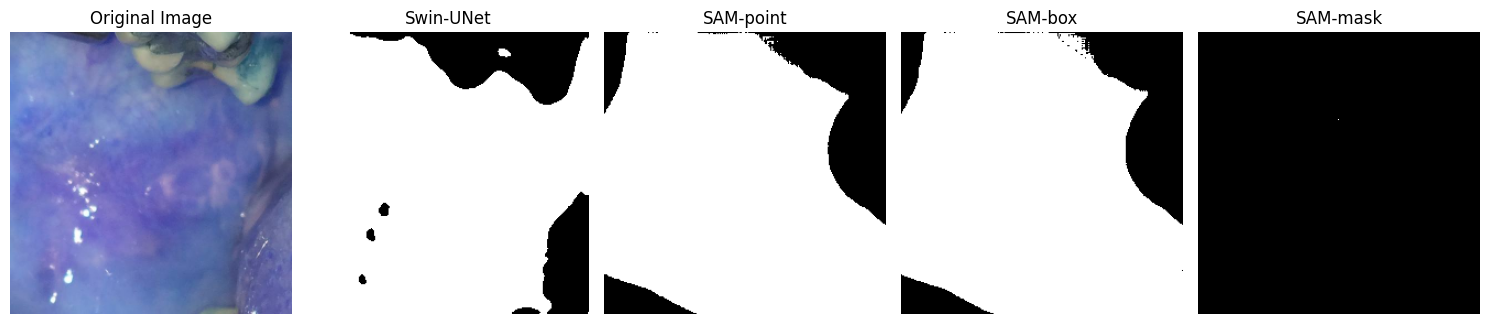

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,5,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Swin-UNet")
plt.axis("off")

for i, prompt in enumerate(["point","box","mask"]):

    plt.subplot(1,5,i+3)
    plt.imshow(results[prompt]["example_mask"], cmap="gray")
    plt.title(f"SAM-{prompt}")
    plt.axis("off")

plt.tight_layout()
plt.show()

PSA

Create a validation dataset and loade

In [ ]:
from torch.utils.data import DataLoader, Dataset
import torch
import numpy as np

# Example Dataset class
class OralCancerDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))  # grayscale
        if self.transform:
            image = self.transform(image)
        return image, mask

# Assume you have lists of file paths:
val_image_paths = [...]  # list of validation image file paths
val_mask_paths = [...]   # corresponding mask file paths

# Create Dataset
validation_dataset = OralCancerDataset(val_image_paths, val_mask_paths)

# Create DataLoader
validation_loader = DataLoader(validation_dataset, batch_size=1, shuffle=False)

In [ ]:
from torch.utils.data import DataLoader, Dataset
import numpy as np
from PIL import Image  # <-- add this

class OralCancerDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))  # grayscale
        if self.transform:
            image = self.transform(image)
        return image, mask

Run evaluation

In [ ]:
results = {}
for prompt in ["point", "box", "mask"]:
    print("Running:", prompt)
    results[prompt] = evaluate_prompt(prompt, valid_loader)

Running: point
Running: box
Running: mask


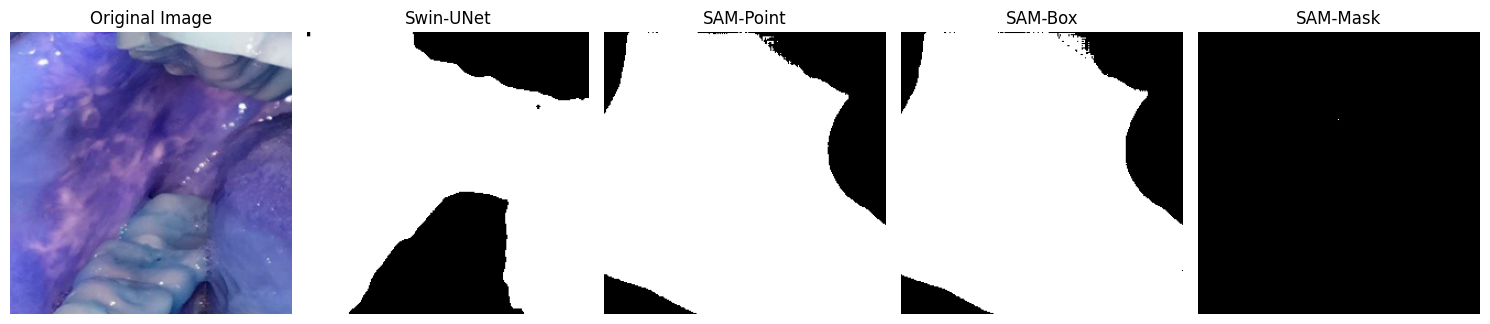

In [ ]:
# get one batch
images, masks = next(iter(valid_loader))

idx = 2   # choose any image index

image_tensor = images[idx]

# convert tensor → image for visualization
image_np = image_tensor.cpu().permute(1,2,0).numpy()
image_np = (image_np - image_np.min())/(image_np.max()-image_np.min())
image_np = (image_np*255).astype("uint8")

# Swin-UNet prediction
with torch.no_grad():
    pred = torch.sigmoid(model(image_tensor.unsqueeze(0).cuda()))

swin_mask = pred.squeeze().cpu().numpy()

# threshold
swin_mask_bin = (swin_mask > 0.5).astype("uint8")

# SAM masks from your results dictionary
sam_point = results["point"]["example_mask"]
sam_box   = results["box"]["example_mask"]
sam_mask  = results["mask"]["example_mask"]

# visualization
plt.figure(figsize=(15,5))

plt.subplot(1,5,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(swin_mask_bin, cmap="gray")
plt.title("Swin-UNet")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(sam_point, cmap="gray")
plt.title("SAM-Point")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(sam_box, cmap="gray")
plt.title("SAM-Box")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(sam_mask, cmap="gray")
plt.title("SAM-Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

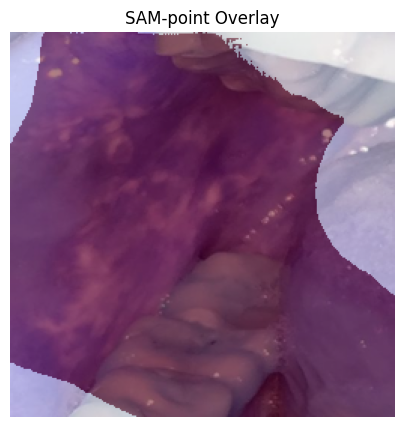

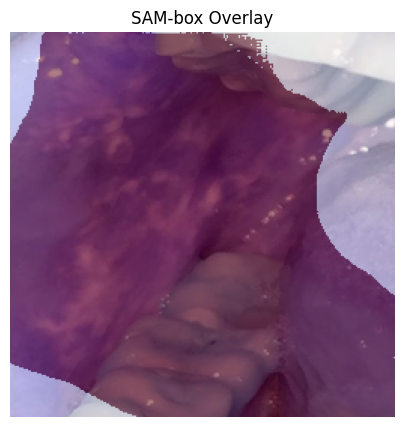

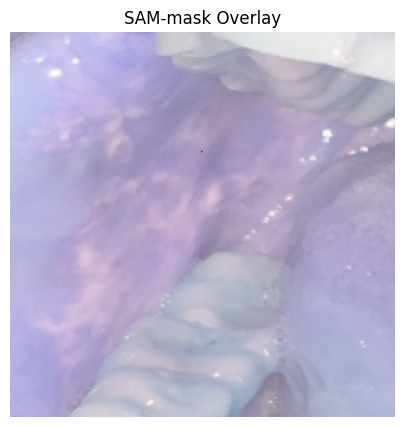

In [ ]:
for i, prompt in enumerate(["point", "box", "mask"]):
    plt.figure(figsize=(5,5))
    plt.imshow(image_np)  # replace with one sample image
    plt.imshow(results[prompt]["example_mask"], alpha=0.5, cmap='Reds')  # semi-transparent overlay
    plt.title(f"SAM-{prompt} Overlay")
    plt.axis('off')
    plt.show()

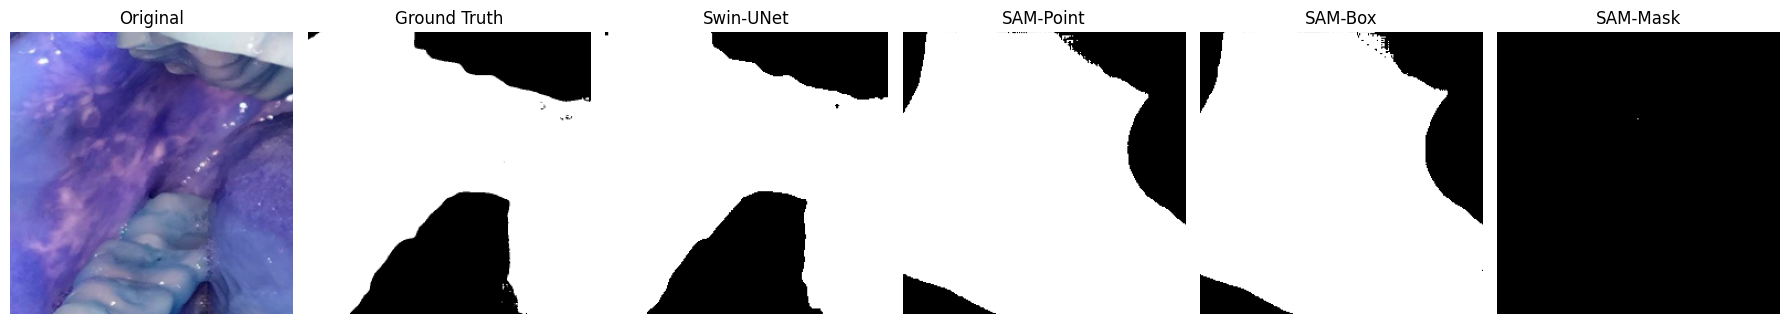

In [ ]:
# get one validation batch
images, masks = next(iter(valid_loader))

idx = 2   # choose sample index

image_tensor = images[idx]
gt_mask = masks[idx].cpu().numpy().squeeze()

# convert tensor → image
image_np = image_tensor.cpu().permute(1,2,0).numpy()
image_np = (image_np - image_np.min())/(image_np.max()-image_np.min())
image_np = (image_np*255).astype("uint8")

# Swin-UNet prediction
with torch.no_grad():
    pred = torch.sigmoid(model(image_tensor.unsqueeze(0).cuda()))

swin_mask = pred.squeeze().cpu().numpy()
swin_mask_bin = (swin_mask > 0.5).astype("uint8")

# SAM masks
sam_point = results["point"]["example_mask"]
sam_box   = results["box"]["example_mask"]
sam_mask  = results["mask"]["example_mask"]

# visualization
plt.figure(figsize=(18,5))

plt.subplot(1,6,1)
plt.imshow(image_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,6,2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,6,3)
plt.imshow(swin_mask_bin, cmap="gray")
plt.title("Swin-UNet")
plt.axis("off")

plt.subplot(1,6,4)
plt.imshow(sam_point, cmap="gray")
plt.title("SAM-Point")
plt.axis("off")

plt.subplot(1,6,5)
plt.imshow(sam_box, cmap="gray")
plt.title("SAM-Box")
plt.axis("off")

plt.subplot(1,6,6)
plt.imshow(sam_mask, cmap="gray")
plt.title("SAM-Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

compare all models

In [ ]:
import torch

def evaluate_models(data_loader):

    results = {
        "Swin-UNet": {"dice":0,"iou":0,"precision":0,"recall":0},
        "SAM-point": {"dice":0,"iou":0,"precision":0,"recall":0},
        "SAM-box": {"dice":0,"iou":0,"precision":0,"recall":0},
        "SAM-mask": {"dice":0,"iou":0,"precision":0,"recall":0}
    }

    count = 0

    model.eval()

    with torch.no_grad():

        for images, masks in data_loader:

            images = images.cuda()
            masks = masks.cuda()

            preds = torch.sigmoid(model(images))

            for i in range(len(images)):

                image_np = images[i].permute(1,2,0).cpu().numpy()
                image_np = (image_np - image_np.min())/(image_np.max()-image_np.min())
                image_np = (image_np*255).astype(np.uint8)

                gt_mask = masks[i].cpu().numpy().squeeze()
                gt_mask_bin = (gt_mask>0.5).astype(np.uint8)

                swin_mask = preds[i].cpu().numpy().squeeze()
                swin_mask_bin = (swin_mask>0.5).astype(np.uint8)

                y_true = gt_mask_bin.flatten()
                y_pred = swin_mask_bin.flatten()

                # Swin-UNet metrics
                results["Swin-UNet"]["dice"] += dice_score(swin_mask_bin,gt_mask_bin)
                results["Swin-UNet"]["iou"] += iou_score(swin_mask_bin,gt_mask_bin)
                results["Swin-UNet"]["precision"] += precision_score(y_true,y_pred,zero_division=0)
                results["Swin-UNet"]["recall"] += recall_score(y_true,y_pred,zero_division=0)

                # SAM prompts
                for prompt in ["point","box","mask"]:

                    sam_mask = run_sam_prompt(image_np,prompt,swin_mask)

                    sam_bin = (sam_mask>0.5).astype(np.uint8)

                    y_pred_sam = sam_bin.flatten()

                    results[f"SAM-{prompt}"]["dice"] += dice_score(sam_bin,gt_mask_bin)
                    results[f"SAM-{prompt}"]["iou"] += iou_score(sam_bin,gt_mask_bin)
                    results[f"SAM-{prompt}"]["precision"] += precision_score(y_true,y_pred_sam,zero_division=0)
                    results[f"SAM-{prompt}"]["recall"] += recall_score(y_true,y_pred_sam,zero_division=0)

                count += 1

    for m in results:
        for k in results[m]:
            results[m][k] /= count

    return results

In [ ]:
results = evaluate_models(valid_loader)

for model_name,metrics in results.items():

    print("\n",model_name)
    print("Dice:",metrics["dice"])
    print("IoU:",metrics["iou"])
    print("Precision:",metrics["precision"])
    print("Recall:",metrics["recall"])


 Swin-UNet
Dice: 0.9006771774324945
IoU: 0.8642009796704712
Precision: 0.9315312485048064
Recall: 0.9032021840456631

 SAM-point
Dice: 0.8341538108834623
IoU: 0.8071776053344497
Precision: 0.9168321779350119
Recall: 0.8154744392844273

 SAM-box
Dice: 0.9409464248770716
IoU: 0.9142444691032664
Precision: 0.9468863028774769
Recall: 0.9385699423962773

 SAM-mask
Dice: 0.03191529201575023
IoU: 0.019321810448082025
Precision: 0.40388433248609296
Recall: 0.019347009168852874


In [ ]:
import pandas as pd

df = pd.DataFrame(results).T
print(df)

               dice       iou  precision    recall
Swin-UNet  0.900677  0.864201   0.931531  0.903202
SAM-point  0.834154  0.807178   0.916832  0.815474
SAM-box    0.940946  0.914244   0.946886  0.938570
SAM-mask   0.031915  0.019322   0.403884  0.019347


In [ ]:
results = {}
for prompt in ["point", "box", "mask"]:
    print("Running:", prompt)
    results[prompt] = evaluate_prompt(prompt, valid_loader)

Running: point
Running: box
Running: mask


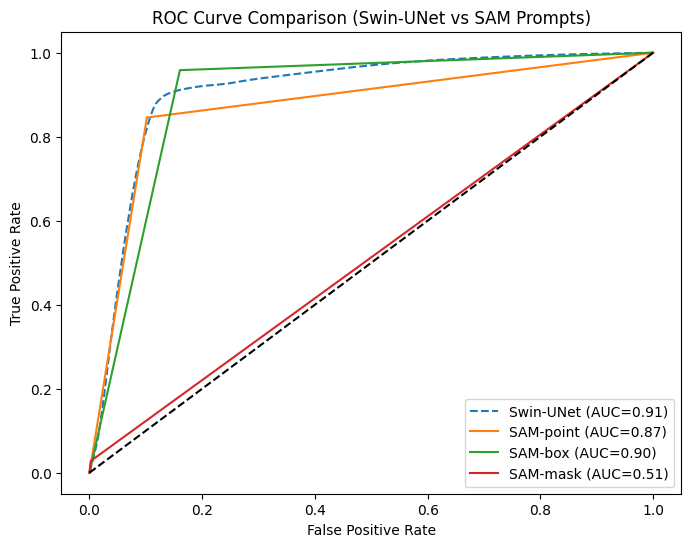

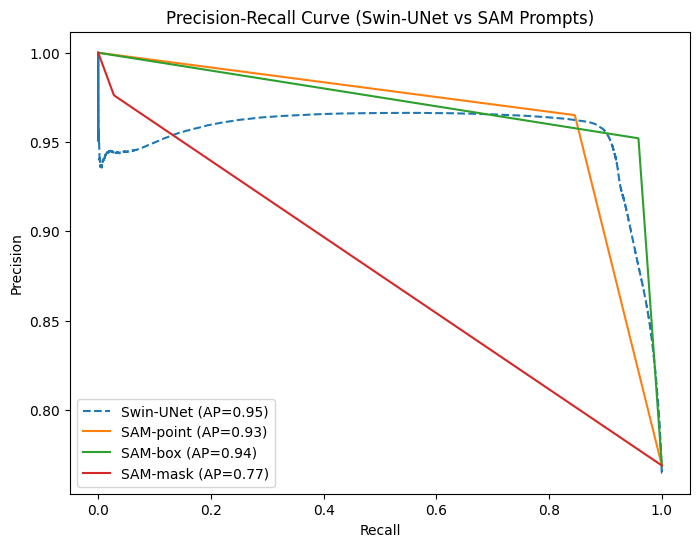

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

# Ground truth (from previous Swin-UNet evaluation)
y_true_unet_baseline = np.array(all_labels) # all_labels from flb_OAyx7uqQ

# Swin-UNet probability prediction baseline (from previous Swin-UNet evaluation)
y_swin_unet_probs = np.array(all_probs) # all_probs from flb_OAyx7uqQ

# ============================
# ROC Curve
# ============================

plt.figure(figsize=(8,6))

# Swin-UNet baseline
fpr, tpr, _ = roc_curve(y_true_unet_baseline, y_swin_unet_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr,
         label=f"Swin-UNet (AUC={roc_auc:.2f})",
         linestyle='--')

# SAM prompts
for prompt in ["point","box","mask"]:

    # Ensure the results dictionary from evaluate_prompt (cell 79dwEAYt-nOM) is used
    fpr, tpr, _ = roc_curve(results[prompt]["Labels"],
                            results[prompt]["Probs"])

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"SAM-{prompt} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Swin-UNet vs SAM Prompts)")
plt.legend()
plt.show()

# ============================
# Precision-Recall Curve
# ============================

plt.figure(figsize=(8,6))

# Swin-UNet baseline
precision, recall, _ = precision_recall_curve(y_true_unet_baseline, y_swin_unet_probs)
ap = average_precision_score(y_true_unet_baseline, y_swin_unet_probs)

plt.plot(recall, precision,
         label=f"Swin-UNet (AP={ap:.2f})",
         linestyle='--')

# SAM prompts
for prompt in ["point","box","mask"]:

    # Ensure the results dictionary from evaluate_prompt (cell 79dwEAYt-nOM) is used
    precision, recall, _ = precision_recall_curve(
        results[prompt]["Labels"],
        results[prompt]["Probs"]
    )

    ap = average_precision_score(
        results[prompt]["Labels"],
        results[prompt]["Probs"]
    )

    plt.plot(recall, precision,
             label=f"SAM-{prompt} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Swin-UNet vs SAM Prompts)")
plt.legend()
plt.show()

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 45.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=58ae0a49cb496dd7affc2f77d3273eadafef125f8cef1ca62cb3b3199f1ca5f5
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
model.eval()

Unet(
  (encoder): MixVisionTransformerEncoder(
    (patch_embed1): OverlapPatchEmbed(
      (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed2): OverlapPatchEmbed(
      (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed3): OverlapPatchEmbed(
      (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed4): OverlapPatchEmbed(
      (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (block1): Sequential(
      (0): Block(
        (norm1): LayerNorm((32,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (q): Linear(in_features=32, o

In [ ]:
print(model)

Unet(
  (encoder): MixVisionTransformerEncoder(
    (patch_embed1): OverlapPatchEmbed(
      (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed2): OverlapPatchEmbed(
      (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed3): OverlapPatchEmbed(
      (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed4): OverlapPatchEmbed(
      (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (block1): Sequential(
      (0): Block(
        (norm1): LayerNorm((32,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (q): Linear(in_features=32, o

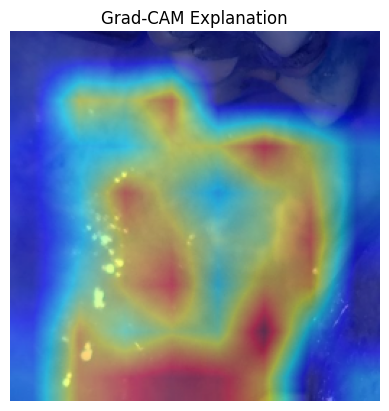

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget # Import for segmentation target

model.eval()

# choose target layer
target_layer = model.encoder.block4[-1] # Corrected from model.encoder.layer4

cam = GradCAM(model=model, target_layers=[target_layer])

images, masks = next(iter(valid_loader))

images = images.cuda()

idx = 5
input_tensor = images[idx].unsqueeze(0)

# Get the model's raw output for the input_tensor
output_from_model = model(input_tensor)
# Convert to probabilities and detach for use as a target mask in numpy format
# Squeeze to remove batch and channel dimensions, as SemanticSegmentationTarget expects (H, W)
target_prediction_mask = torch.sigmoid(output_from_model).detach().cpu().squeeze().numpy()

# Define the target for GradCAM. For a binary segmentation model with classes=1,
# we target category 0 (the only class) and use the predicted mask as the region of interest.
targets = [SemanticSegmentationTarget(category=0, mask=target_prediction_mask)]

# generate heatmap, passing the defined targets
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# convert image for visualization (normalize to 0-1 range)
image = images[idx].cpu().permute(1,2,0).numpy()
image = (image - image.min())/(image.max()-image.min())

# overlay heatmap
visualization = show_cam_on_image(image, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title("Grad-CAM Explanation")
plt.axis("off")
plt.show()

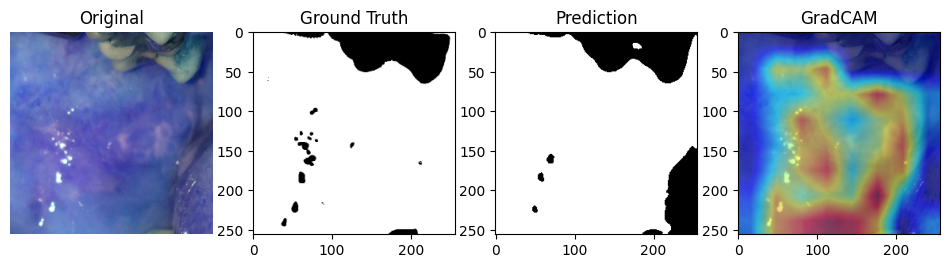

In [ ]:
preds = torch.sigmoid(model(images))
pred_mask = preds[idx].cpu().squeeze().detach().numpy()
pred_mask = (pred_mask > 0.5).astype(np.uint8)

true_mask = masks[idx].cpu().squeeze().detach().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(true_mask,cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,4,3)
plt.imshow(pred_mask,cmap="gray")
plt.title("Prediction")

plt.subplot(1,4,4)
plt.imshow(visualization)
plt.title("GradCAM")

plt.show()

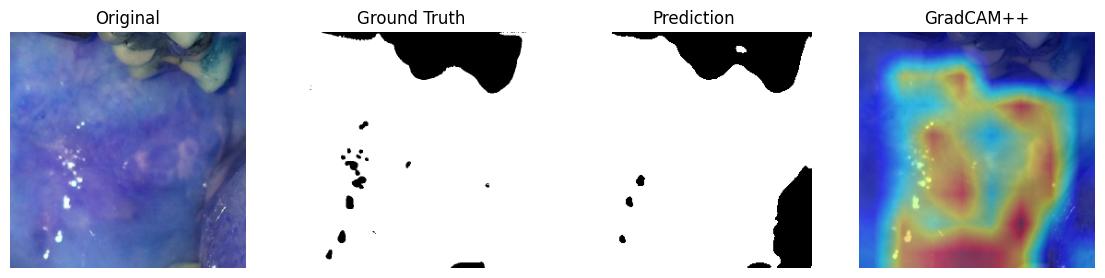

In [ ]:
preds = torch.sigmoid(model(images))

pred_mask = preds[idx].cpu().squeeze().detach().numpy()
pred_mask = (pred_mask > 0.5).astype(np.uint8)

true_mask = masks[idx].cpu().squeeze().detach().numpy()

plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(visualization)
plt.title("GradCAM++")
plt.axis("off")

plt.show()